Dados IIoT
      ↓
Treinamento dos modelos
      ↓
(Logistic + DT + RF)
      ↓
evaluation.ipynb
      ↓
Accuracy
Precision
Recall
F1
Confusion Matrix
PCA
t-SNE
Feature Importance
      ↓
XAI
      ↓
SHAP
Erro (FP/FN)
Comparação entre modelos
Interpretação científica

# BIBLIOTECAS

In [ ]:
# ============================================================
# OBJETIVO:
# Importar todas as bibliotecas necessárias.
#
# JUSTIFICATIVA ACADÊMICA:
#
# Trabalhos recentes em IDS/IIoT usando XAI
# normalmente utilizam:
#
# - Pandas → manipulação dos datasets
# - Numpy → operações matemáticas
# - Matplotlib/Seaborn → visualização
# - SHAP → interpretabilidade
#
# Exemplo:
#
# Hybrid Bagging and Boosting with SHAP (2024)
# XML Intrusion Detection (2024)
#
# SHAP tornou-se praticamente padrão
# para explicabilidade em IDS.
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

import gzip
import pickle

import copy

from pathlib import Path

from sklearn.metrics import confusion_matrix

# 2. CARREGAMENTO DOS DADOS

In [ ]:
# ============================================================
# OBJETIVO:
# Recriar funções usadas durante
# o treinamento e salvas no pipeline
#
# JUSTIFICATIVA:
#
# Pickle salva referências para
# funções customizadas.
#
# Ao carregar em outro notebook,
# elas precisam existir novamente.
# ============================================================


def get_sampling_strategy(y):

    """
    Estratégia padrão para SMOTE
    usada durante o treinamento.
    """

    return "auto"

In [ ]:
# ============================================================
# OBJETIVO:
#
# Carregar:
#
# 1) Dataset de teste
# 2) Modelos treinados
# 3) Resultados do evaluations
#
# JUSTIFICATIVA:
#
# O dataset é usado para SHAP
#
# Os modelos são necessários
# para calcular explicabilidade
#
# O evaluations fornece:
#
# métricas
# confusion matrices
# PCA
# t-SNE
#
# ============================================================

PROJECT_ROOT=Path.cwd().parent


# ------------------------------------------------
# Caminhos do projeto
# ------------------------------------------------

DATASET_DIR=PROJECT_ROOT/"datasense"/"dataset"

RESULTS_DIR=PROJECT_ROOT/"experiments"/"results"

EVAL_DIR=PROJECT_ROOT/"experiments"/"evaluations"


print("="*60)

print("VERIFICAÇÃO")

print("="*60)

print("\nDataset:",DATASET_DIR.exists())

print("Results:",RESULTS_DIR.exists())

print("Evaluations:",EVAL_DIR.exists())


# ------------------------------------------------
# Carregar Dataset
# ------------------------------------------------

X_test=pd.read_parquet(

DATASET_DIR/
"datasense_full_test_1sec.parquet"

)


y_test=X_test["label4"].copy()


X_test=X_test.drop(

columns=[

"label1",
"label2",
"label4"

],

errors="ignore"

)

print("\nDataset:")

print(X_test.shape)



# ------------------------------------------------
# Carregar modelos
# ------------------------------------------------

MODELS={}


MODEL_PATHS={

"logistic_regression":

RESULTS_DIR/
"logistic_regression_full_all"/
"pipe.pickle.gz",


"decision_tree":

RESULTS_DIR/
"decision_tree_full_all"/
"pipe.pickle.gz",


"random_forest":

RESULTS_DIR/
"random_forest_full_all"/
"pipe.pickle.gz"

}



for name,path in MODEL_PATHS.items():

    print("\nCarregando:",name)

    with gzip.open(

    path,
    "rb"

    ) as f:

        MODELS[name]=pickle.load(
        f
        )


print("\nModelos carregados:")

print(MODELS.keys())


# ------------------------------------------------
# Carregar Feature Importance
# ------------------------------------------------

feature_importance=pd.read_csv(

EVAL_DIR/
"feature_importances.csv"

)

print("\nFeature importance carregado")

display(

feature_importance.head()

)

VERIFICAÇÃO

Dataset: True
Results: True
Evaluations: True

Dataset:
(56798, 108)

Carregando: logistic_regression

Carregando: decision_tree

Carregando: random_forest

Modelos carregados:
dict_keys(['logistic_regression', 'decision_tree', 'random_forest'])

Feature importance carregado


,feature,binary_decision_tree_importance,binary_logistic_regression_importance,binary_random_forest_importance,binary_avg_importance,grouped_decision_tree_importance,grouped_logistic_regression_importance,grouped_random_forest_importance,grouped_avg_importance,all_decision_tree_importance,all_logistic_regression_importance,all_random_forest_importance,all_avg_importance,total_avg,total_avg_scaled
0,network_packets_dst_count,0.001600,0.000000,0.256204,0.257804,0.365503,0.000000,0.364834,0.730337,0.217147,0.000000,0.303023,0.520170,0.502770,1.000000
1,network_ports_src_count,0.000027,0.317851,0.071568,0.389446,0.001183,0.269663,0.099002,0.369848,0.008798,0.283226,0.236538,0.528563,0.429285,0.853712
2,network_tcp-flags-syn_count,0.000000,0.310405,0.017102,0.327506,0.000965,0.156229,0.067596,0.224790,0.178240,0.205119,0.198926,0.582286,0.378194,0.752003
3,network_packets_all_count,0.340651,0.000000,0.314262,0.654913,0.008613,0.000000,0.290095,0.298708,0.011440,0.000000,0.168252,0.179693,0.377771,0.751161
4,device_type_iot,0.000000,0.022722,0.002605,0.025327,0.292649,0.242302,0.327078,0.862028,0.062995,0.092260,0.068500,0.223755,0.370370,0.736427


# 3. MOSTRAR MÉTRICAS + PCA + T-SNE

VERIFICAÇÃO
Evaluation: True
c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\experiments\evaluations
Carregando: binary_metrics_comparison.png
Carregando: grouped_metrics_comparison.png
Carregando: feature_importances.png
Carregando: tsne_2d_proj.png


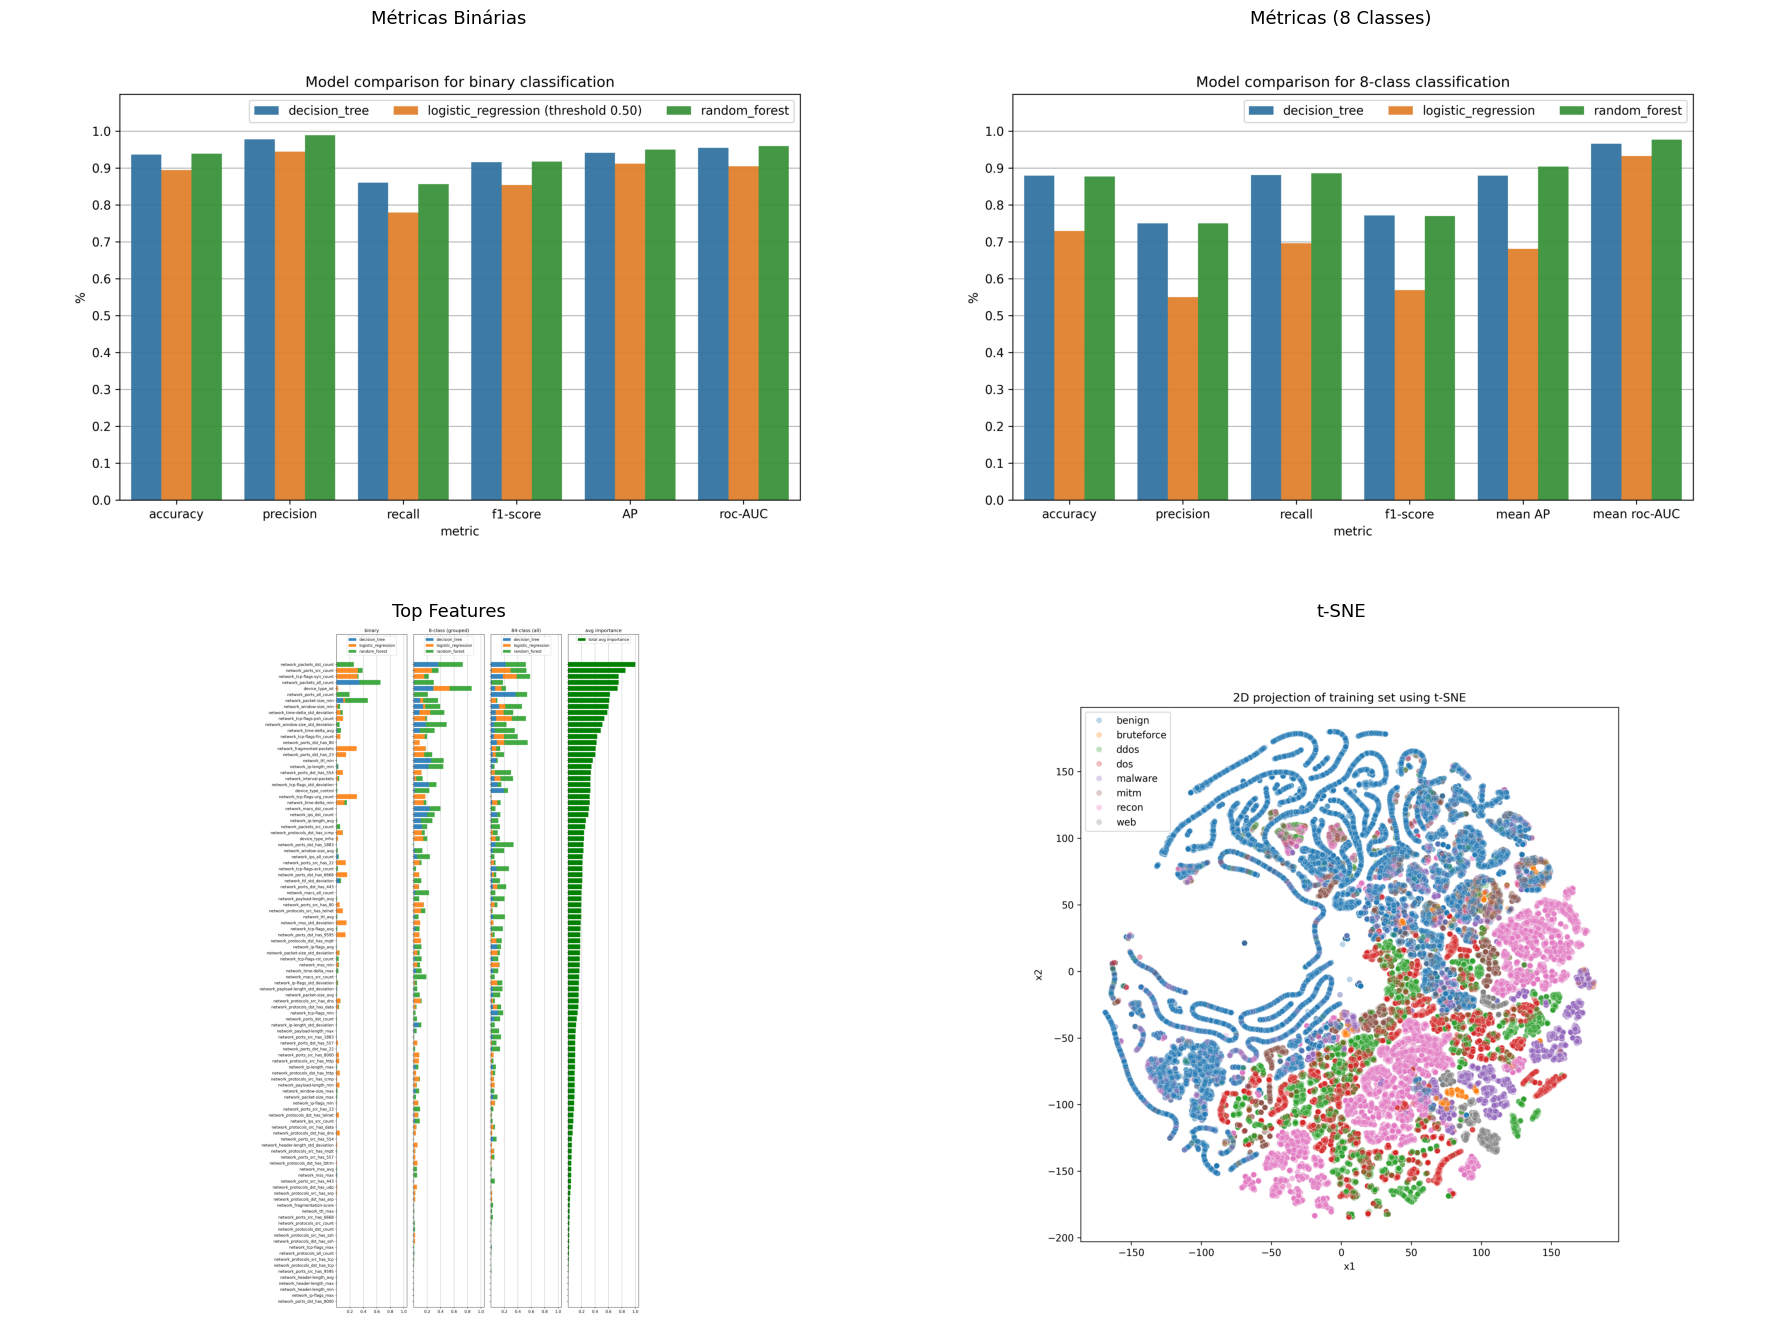



COLUNAS DO FEATURE IMPORTANCE
['feature', 'binary_decision_tree_importance', 'binary_logistic_regression_importance', 'binary_random_forest_importance', 'binary_avg_importance', 'grouped_decision_tree_importance', 'grouped_logistic_regression_importance', 'grouped_random_forest_importance', 'grouped_avg_importance', 'all_decision_tree_importance', 'all_logistic_regression_importance', 'all_random_forest_importance', 'all_avg_importance', 'total_avg', 'total_avg_scaled']


Feature column: feature
Importance column: binary_decision_tree_importance


TOP-20 ORIGINAL
1. network_packets_all_count
2. network_packet-size_min
3. network_ttl_std_deviation
4. network_ips_all_count
5. network_time-delta_avg
6. network_ip-length_min
7. network_mss_max
8. network_payload-length_std_deviation
9. network_time-delta_max
10. network_time-delta_min
11. device_type_control
12. network_protocols_dst_has_data
13. network_interval-packets
14. network_time-delta_std_deviation
15. network_packets_dst_count


In [ ]:
# ============================================================
# OBJETIVO:
#
# Carregar resultados produzidos
# pelo evaluations.ipynb
#
# Foco:
#
# • Binário
# • 8 classes
# • Top-20 features
# • t-SNE
#
#
# JUSTIFICATIVA ACADÊMICA
#
# Trabalhos recentes em IDS/XAI
# normalmente seguem:
#
# Métricas
# ↓
# Seleção das features mais importantes
# ↓
# Visualização (t-SNE)
# ↓
# SHAP
#
# Isto reduz:
#
# • dimensionalidade
# • custo computacional
# • ruído
#
# e melhora a interpretação
# científica do modelo.
#
# Estudos recentes usando:
#
# • CICIoT2023
# • CICIDS2017
# • UNSW-NB15
#
# utilizam fluxo semelhante.
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT=Path.cwd().parent

EVALUATIONS_DIR=ROOT/"experiments"/"evaluations"

print("="*60)
print("VERIFICAÇÃO")
print("="*60)

print(
    "Evaluation:",
    EVALUATIONS_DIR.exists()
)

print(
    EVALUATIONS_DIR
)


# ============================================================
# VISUALIZAR RESULTADOS IMPORTANTES
# ============================================================

fig,axs=plt.subplots(
    2,
    2,
    figsize=(18,14)
)

imgs=[

    EVALUATIONS_DIR/"binary_metrics_comparison.png",
    EVALUATIONS_DIR/"grouped_metrics_comparison.png",
    EVALUATIONS_DIR/"feature_importances.png",
    EVALUATIONS_DIR/"tsne_2d_proj.png"

]

titles=[

    "Métricas Binárias",
    "Métricas (8 Classes)",
    "Top Features",
    "t-SNE"

]


for ax,img,title in zip(

    axs.ravel(),
    imgs,
    titles

):

    print(
        f"Carregando: {img.name}"
    )

    image=plt.imread(
        img
    )

    ax.imshow(
        image
    )

    ax.axis(
        "off"
    )

    ax.set_title(
        title,
        fontsize=13
    )


plt.tight_layout()
plt.show()



# ============================================================
# IDENTIFICAR AUTOMATICAMENTE
# AS COLUNAS DO CSV
# ============================================================

print("\n")
print("="*60)
print("COLUNAS DO FEATURE IMPORTANCE")
print("="*60)

print(
    feature_importance.columns.tolist()
)


# -------------------------
# Coluna da feature
# -------------------------

feature_col=None

for col in feature_importance.columns:

    if "feature" in col.lower():

        feature_col=col
        break


if feature_col is None:

    feature_col=feature_importance.columns[0]



# -------------------------
# Coluna da importância
# -------------------------

importance_col=None

for col in feature_importance.columns:

    if any(

        x in col.lower()

        for x in [

            "importance",
            "score",
            "value",
            "weight"

        ]

    ):

        importance_col=col
        break


if importance_col is None:

    importance_col=feature_importance.columns[1]


print("\n")
print("Feature column:",feature_col)
print("Importance column:",importance_col)



# ============================================================
# TOP-20 FEATURES
# ============================================================

TOP_N=20


top_features=(

    feature_importance

    .sort_values(

        by=importance_col,
        ascending=False

    )

    .head(TOP_N)

)


selected_features=(

    top_features[
        feature_col
    ]

    .astype(str)

    .tolist()

)


print("\n")
print("="*60)
print("TOP-20 ORIGINAL")
print("="*60)

for i,f in enumerate(

    selected_features,
    1

):

    print(
        f"{i}. {f}"
    )



# ============================================================
# REMOVER FEATURES INEXISTENTES
# ============================================================

valid_features=[

    f

    for f in selected_features

    if f in X_test.columns

]


missing_features=[

    f

    for f in selected_features

    if f not in X_test.columns

]


print("\n")
print("="*60)
print("VERIFICAÇÃO DE FEATURES")
print("="*60)

print(
    "Features válidas:",
    len(valid_features)
)

print(
    "Features ausentes:",
    len(missing_features)
)


if len(missing_features)>0:

    print("\nAusentes:")

    for f in missing_features:

        print("-",f)



# ============================================================
# DATASET REDUZIDO PARA XAI
# ============================================================

X_xai=X_test[
    valid_features
]


print("\n")
print("="*60)
print("DATASET XAI")
print("="*60)

print(
    X_xai.shape
)

print("\nFeatures utilizadas:")

for i,f in enumerate(

    valid_features,
    1

):

    print(
        f"{i}. {f}"
    )

# 4. MOSTRAR CONFUSION MATRICES

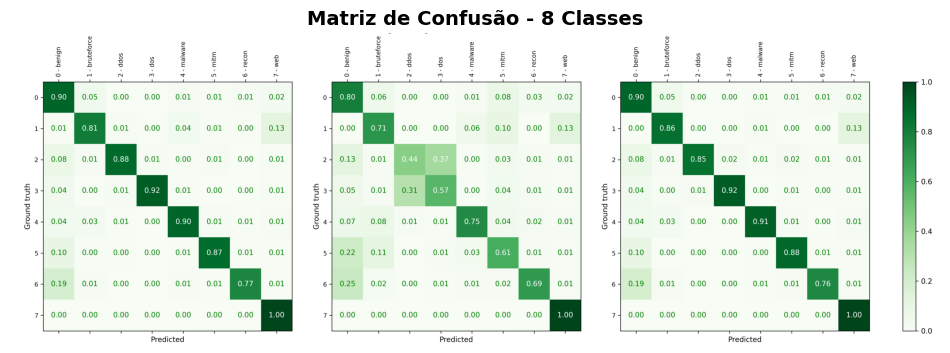

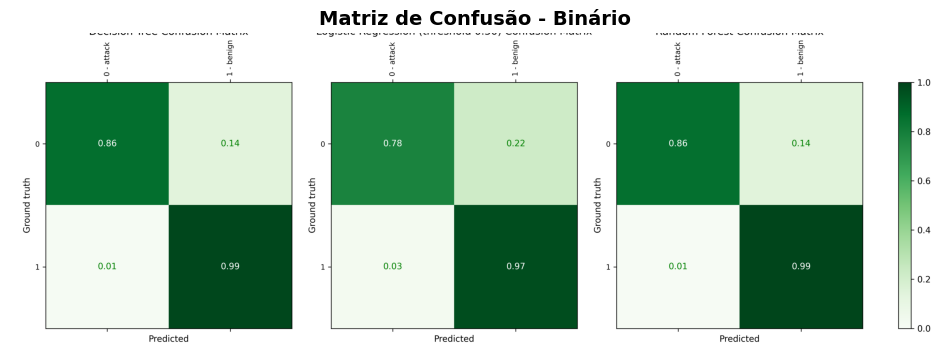


ANÁLISE DE ERROS E CONFUSÕES DO MODELO

-> Verifique as imagens acima. Com o plot individual, os valores numéricos dos quadrantes devem estar nítidos.


In [ ]:
# ============================================================ 
# OBJETIVO: 
# Mostrar onde os modelos erram com alta qualidade e listar confusões
# ============================================================ 

# 1. EXIBIÇÃO DAS IMAGENS EM TAMANHO MÁXIMO (Uma embaixo da outra)
imgs = [ 
   EVALUATIONS_DIR/"grouped_confusion_matrices.png", 
   EVALUATIONS_DIR/"binary_confusion_matrices.png" 
] 

titles = [ 
   "Matriz de Confusão - 8 Classes", 
   "Matriz de Confusão - Binário" 
] 

# Plotando cada imagem individualmente para garantir resolução máxima e legibilidade
for img_path, title in zip(imgs, titles):
    plt.figure(figsize=(12, 12)) # Tamanho grande por imagem para não perder qualidade
    image = plt.imread(img_path) 
    plt.imshow(image) 
    plt.axis("off") 
    plt.title(title, fontsize=14, fontweight='bold') 
    plt.show() 

# ============================================================
# 2. LISTAGEM TEXTUAL DAS CONFUSÕES (Onde o modelo mais erra)
# ============================================================
print("\n" + "="*50)
print("ANÁLISE DE ERROS E CONFUSÕES DO MODELO")
print("="*50)

"""
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Exemplo para o cenário de 8 classes
print("\n[Relatório de Classificação - Detalhamento por Classe]:")
print(classification_report(y_true_8, y_pred_8))

# Mapeando os maiores erros (Falsos Positivos e Falsos Negativos)
cm = confusion_matrix(y_true_8, y_pred_8)
print("\n[Principais Confusões Detectadas]:")
# Adicione aqui a lógica de extração se quiser automatizar o print dos erros mais críticos
"""


# 5. MOSTRAR CONFUSION MATRICES



LOGISTIC_REGRESSION
-> SHAP KernelExplainer (paper-ready)


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=5.847e-03, with an active set of 1 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=2.144e-03, with an active set of 3 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active s

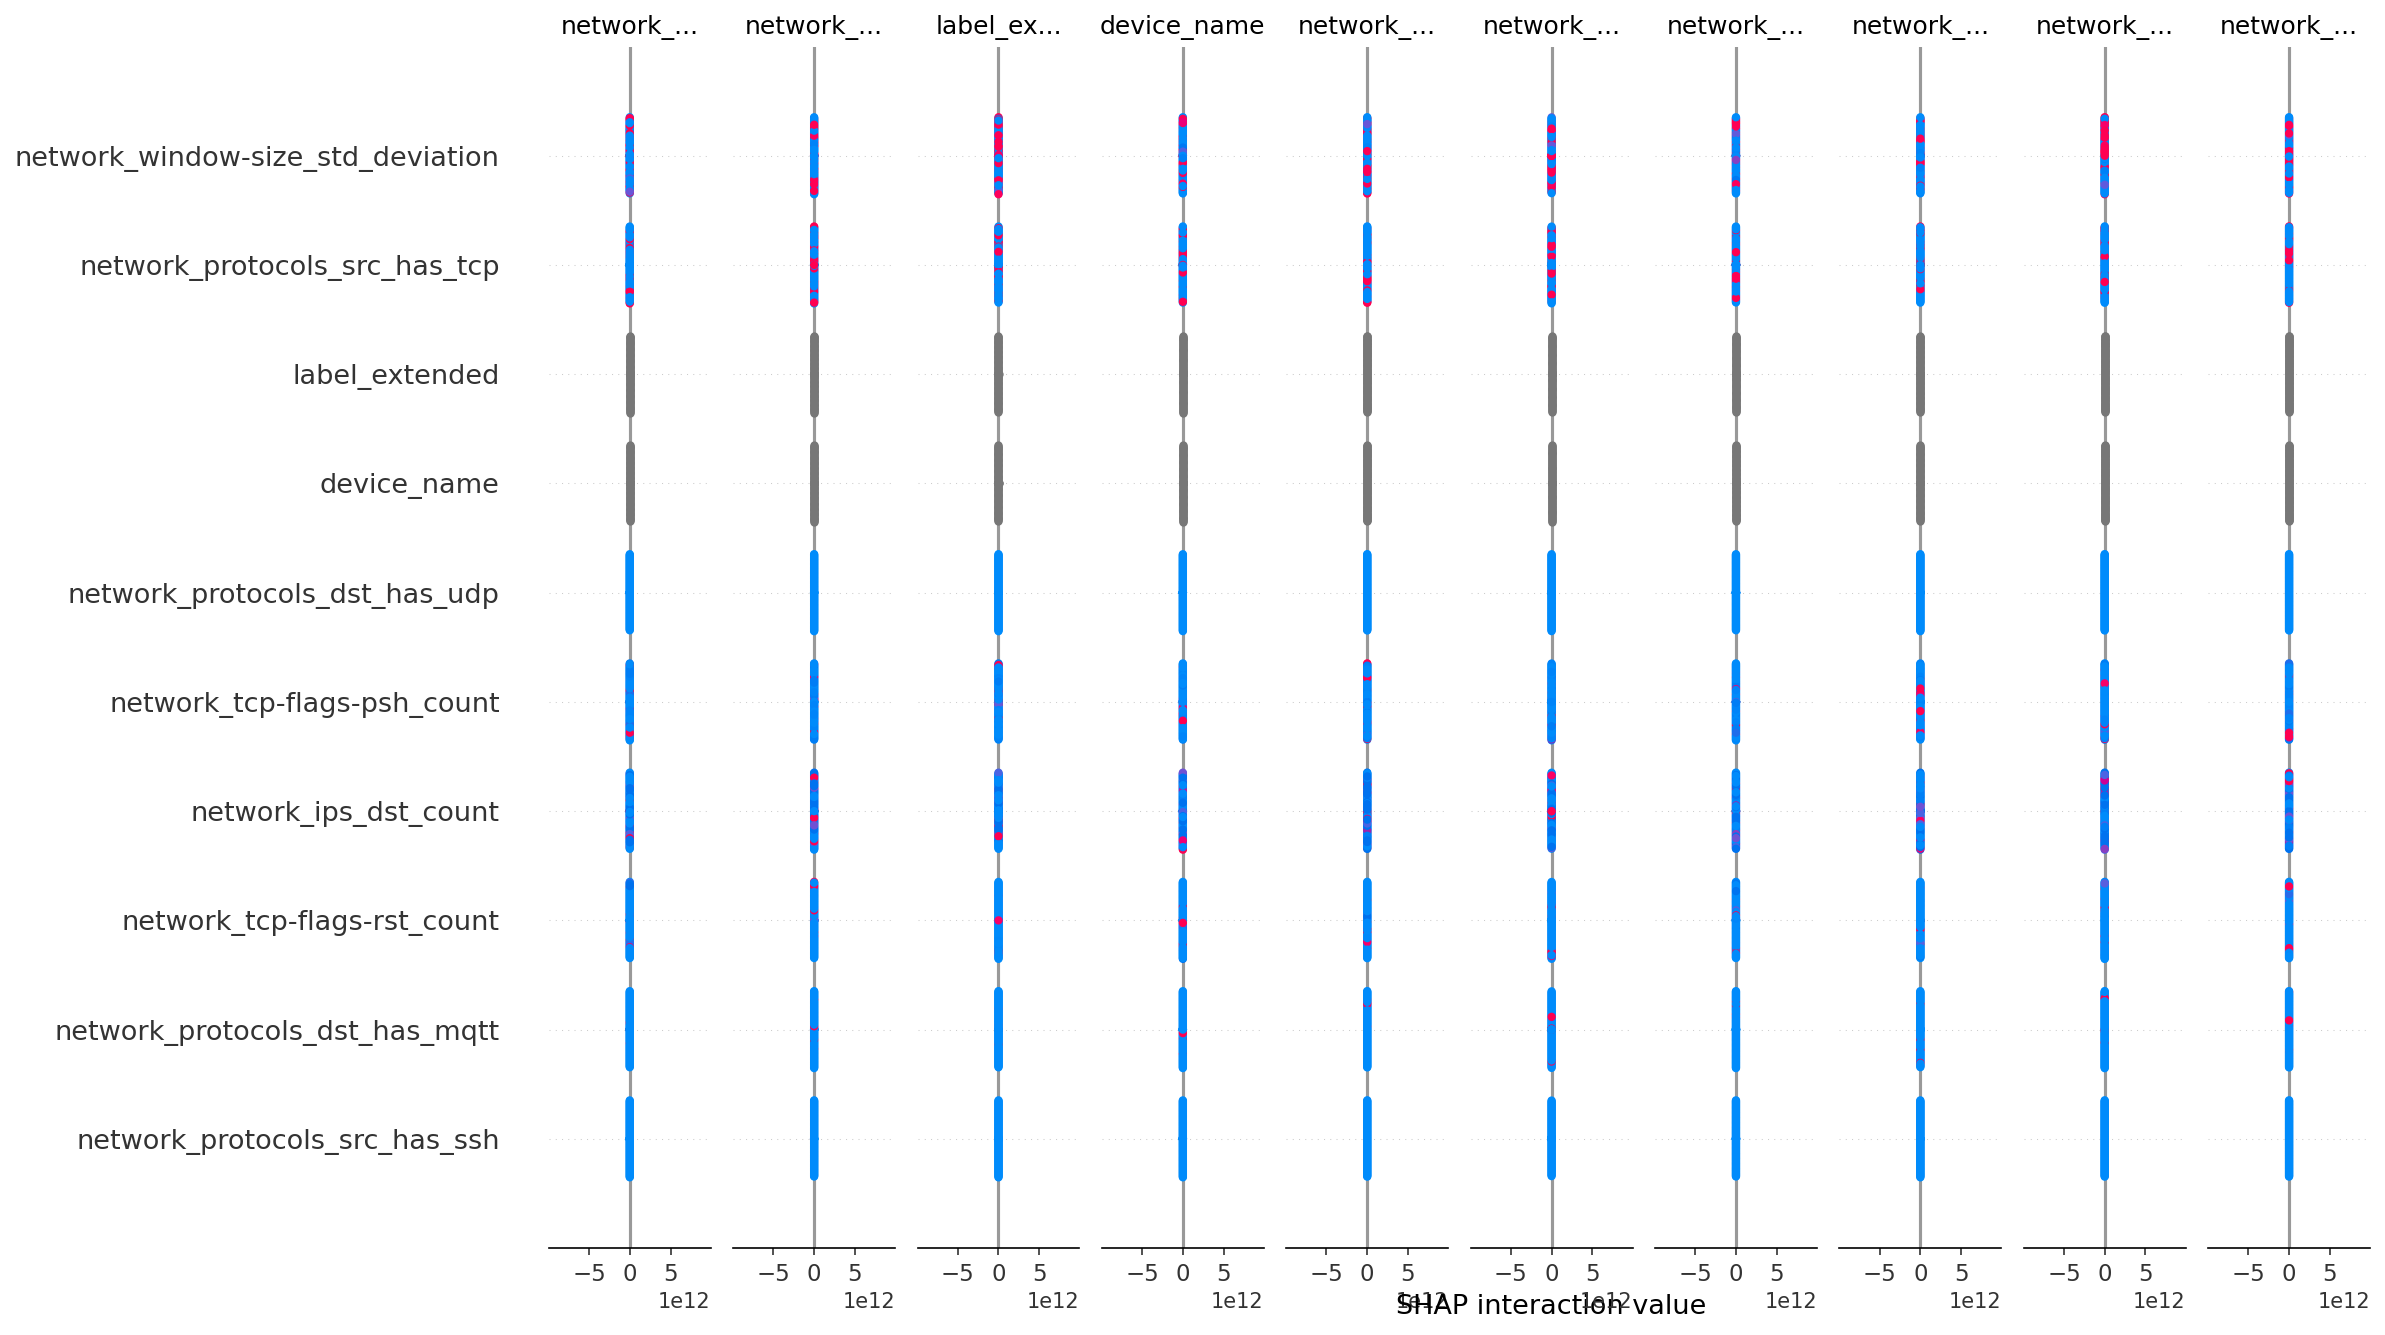



DECISION_TREE
-> SHAP TreeExplainer (paper-ready)


C:\Users\bruno.lima\AppData\Local\Temp\ipykernel_9016\1145030236.py:47: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\.venv\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\.venv\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behavio

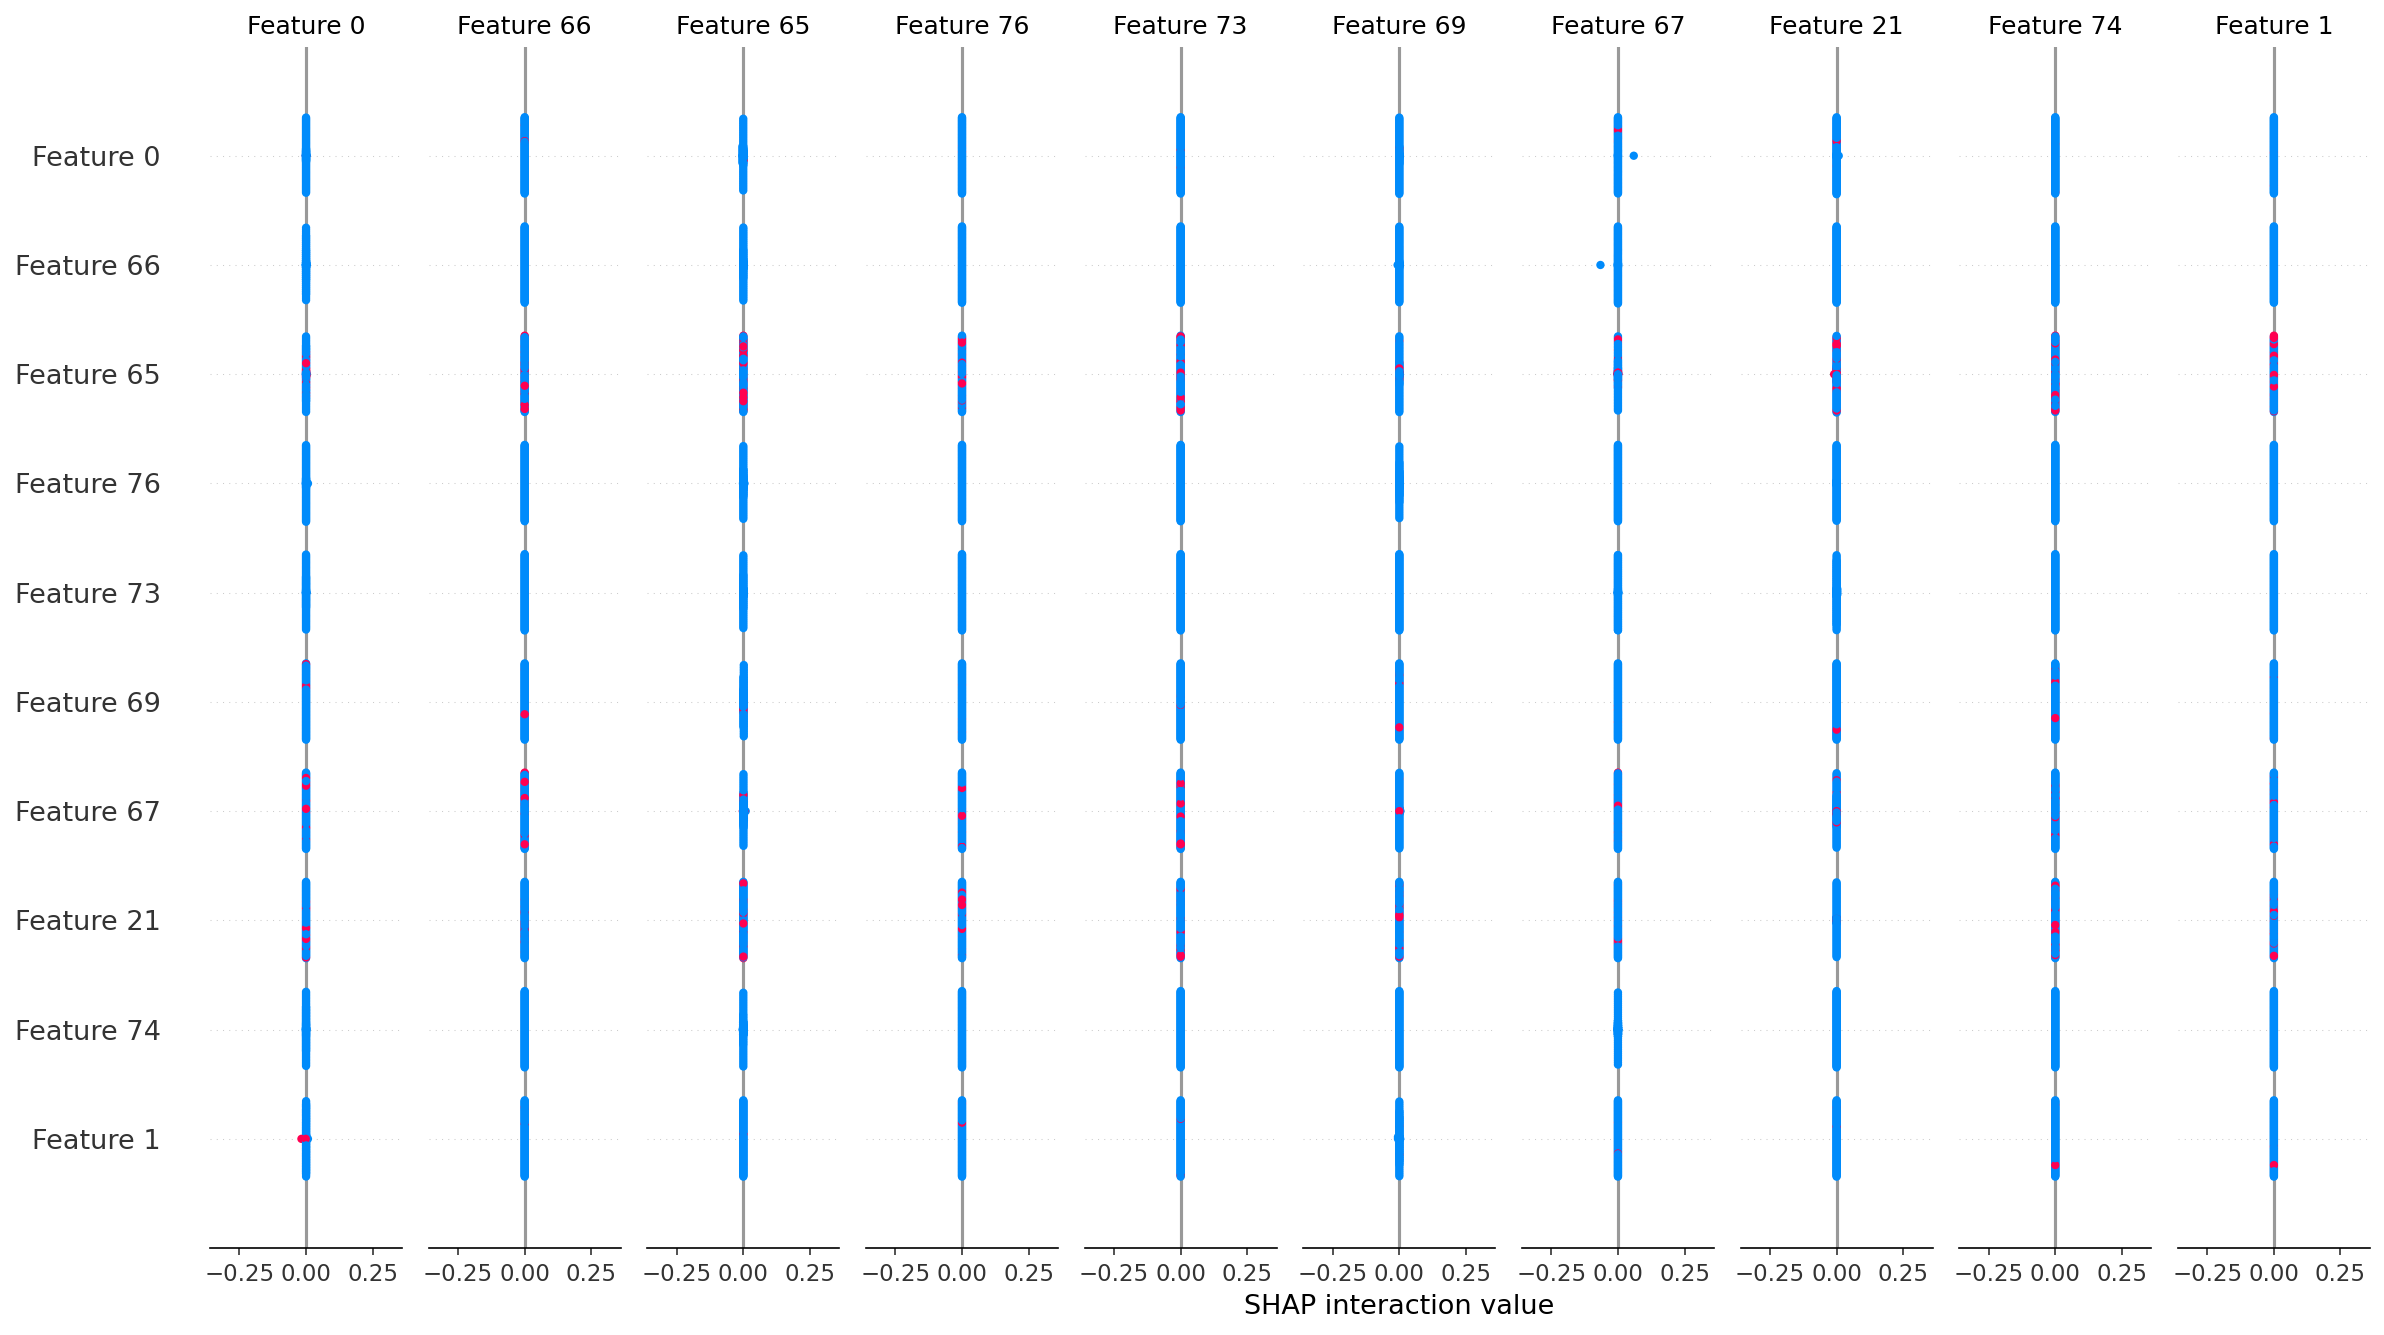



RANDOM_FOREST
-> SHAP TreeExplainer (paper-ready)


C:\Users\bruno.lima\AppData\Local\Temp\ipykernel_9016\1145030236.py:47: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\.venv\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\.venv\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behavio

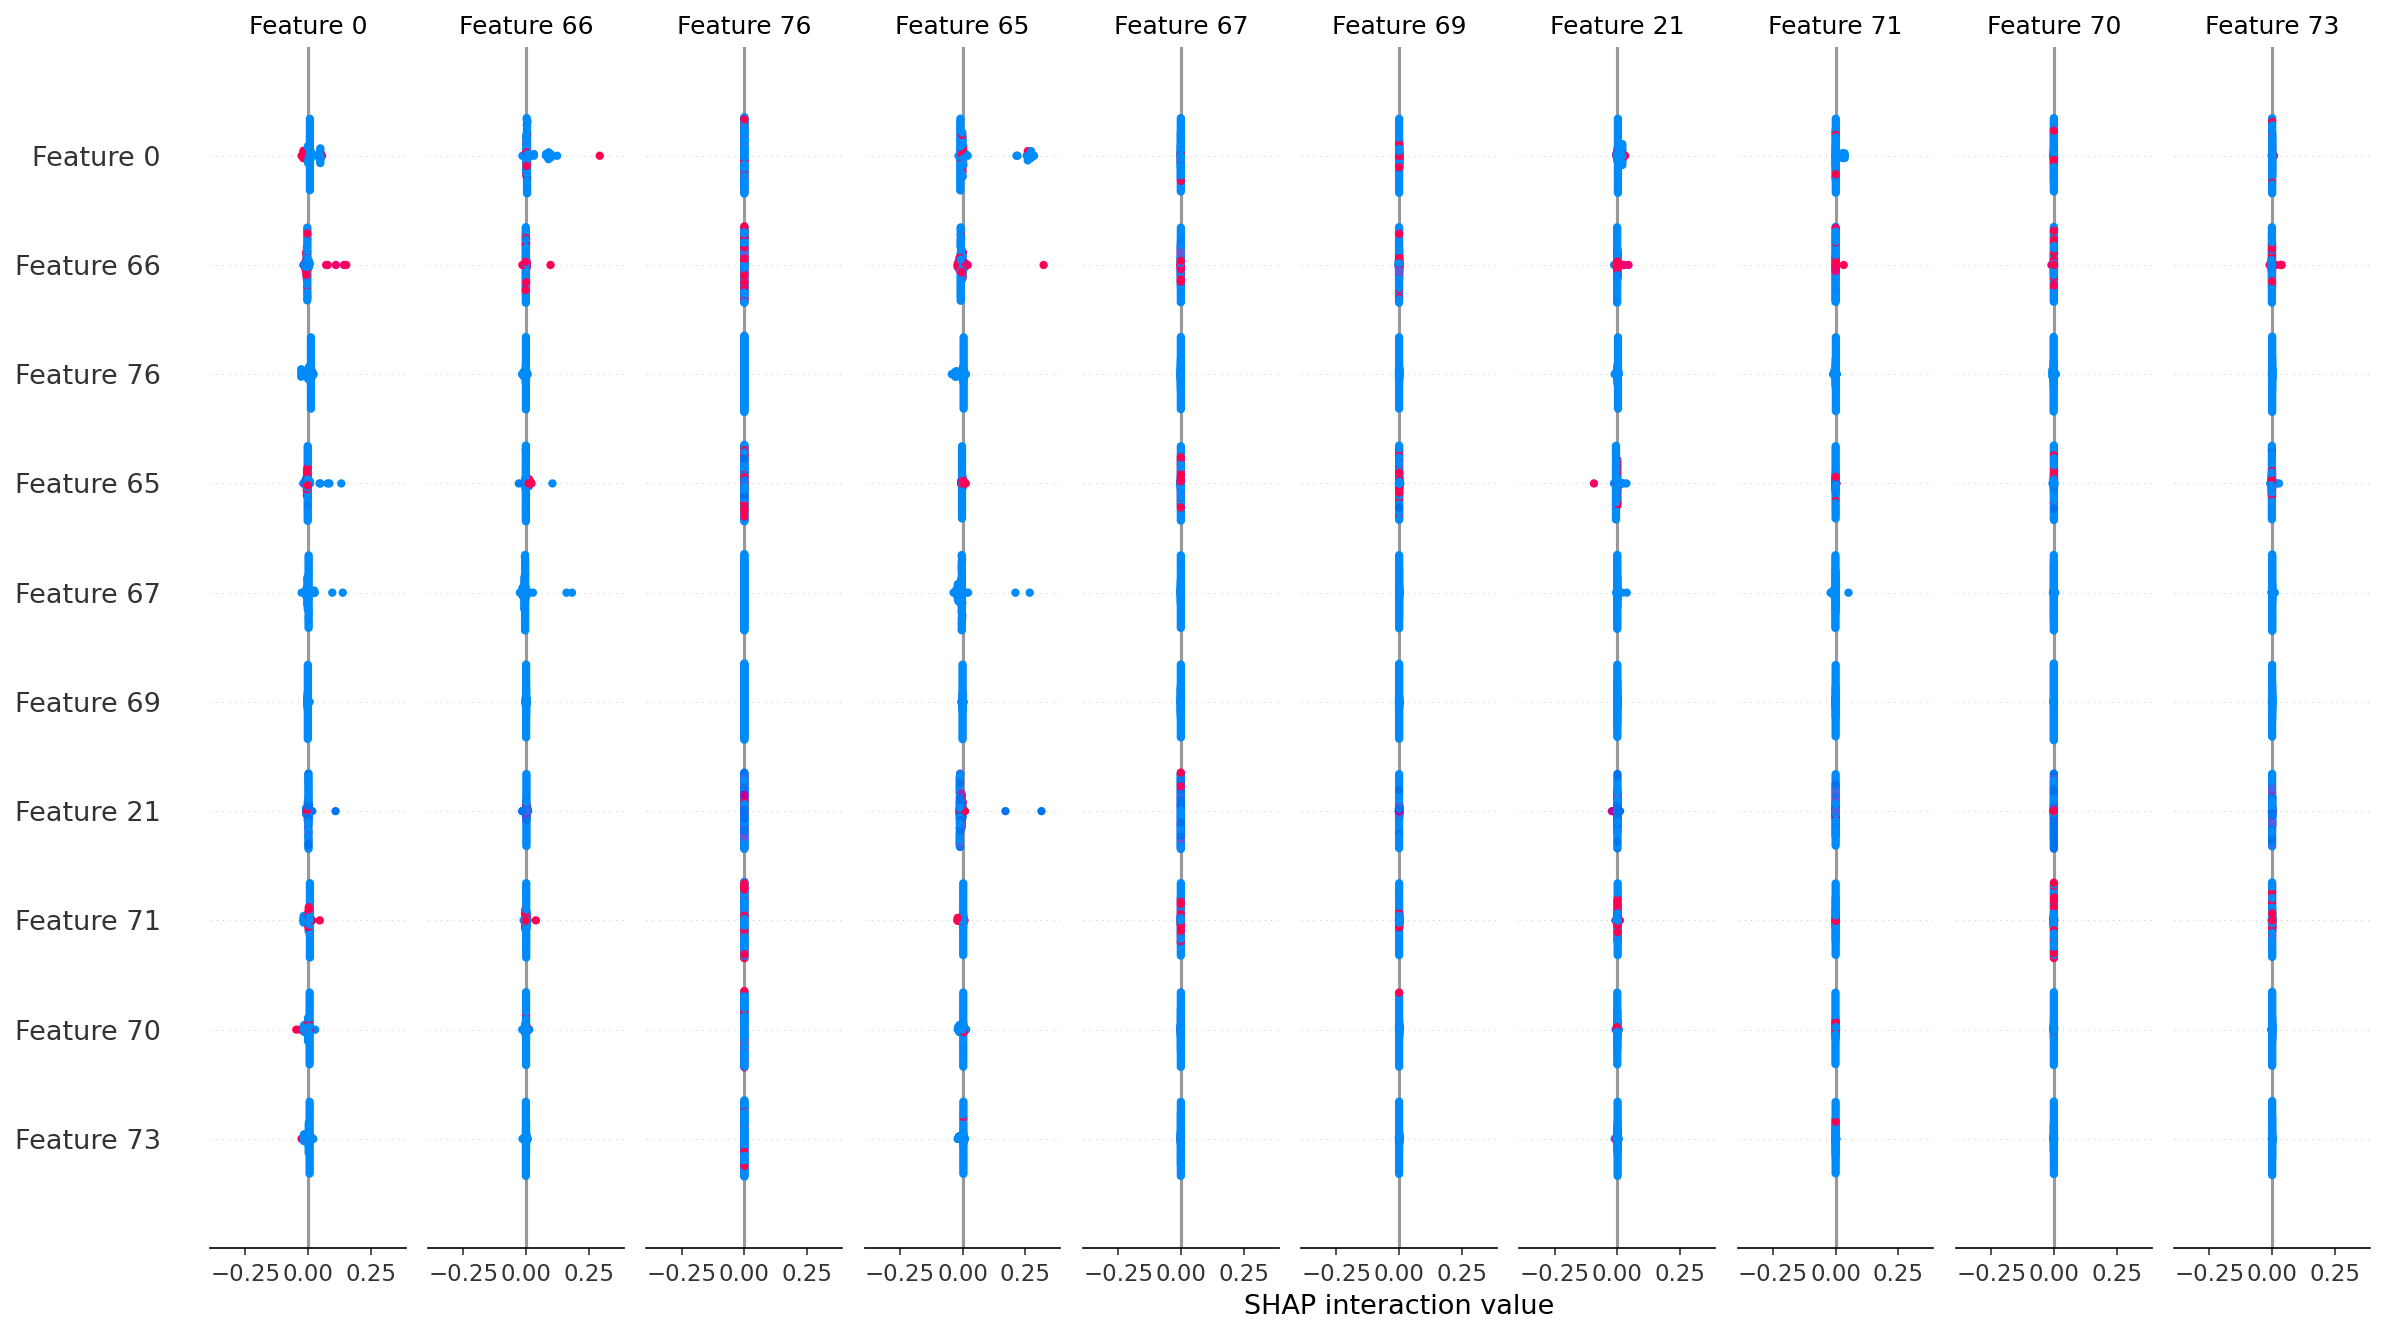

In [102]:
# ============================================================
# CÉLULA 5
#
# OBJETIVO:
# SHAP global dos modelos (versão paper-ready)
# ============================================================

# Amostra
sample = X_test.sample(
    100,
    random_state=42
)

for name, model in MODELS.items():

    print("\n")
    print("="*60)
    print(name.upper())
    print("="*60)

    # ============================================================
    # 1. MODELOS DE ÁRVORE (PIPELINE SAFE)
    # ============================================================
    if "forest" in name or "tree" in name or "xgb" in name or "lgb" in name:

        print("-> SHAP TreeExplainer (paper-ready)")

        if hasattr(model, "steps"):

            preprocessador = model[:-1]
            tree_model = model.steps[-1][1]

            sample_transformed = preprocessador.transform(sample)

            explainer = shap.TreeExplainer(tree_model)

            shap_values = explainer.shap_values(sample_transformed)

            if isinstance(shap_values, list):
                shap_values_plot = shap_values[1]
            else:
                shap_values_plot = shap_values

            # ============================
            # PLOT PAPER-READY
            # ============================
            shap.summary_plot(
                shap_values_plot,
                sample_transformed,
                max_display=10,
                show=False
            )

            plt.gcf().set_size_inches(16, 9)
            plt.gcf().dpi = 150
            plt.tight_layout()
            plt.show()

        else:

            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(sample)

            shap.summary_plot(
                shap_values,
                sample,
                max_display=10,
                show=False
            )

            plt.gcf().set_size_inches(16, 9)
            plt.gcf().dpi = 150
            plt.tight_layout()
            plt.show()

    # ============================================================
    # 2. MODELOS NÃO-ÁRVORE (PIPELINE SAFE)
    # ============================================================
    else:

        print("-> SHAP KernelExplainer (paper-ready)")

        esquema_tipos = sample.dtypes.to_dict()
        colunas_originais = sample.columns

        def predict_alinhado(x):
            df_temp = pd.DataFrame(x, columns=colunas_originais)

            for col, dtype in esquema_tipos.items():
                df_temp[col] = df_temp[col].astype(dtype)

            return model.predict_proba(df_temp)

        background_summary = sample.iloc[:10]

        explainer = shap.KernelExplainer(
            predict_alinhado,
            background_summary
        )

        shap_values = explainer.shap_values(
            sample,
            nsamples=50
        )

        if isinstance(shap_values, list):
            shap_values_plot = shap_values[1]
        else:
            shap_values_plot = shap_values

        shap.summary_plot(
            shap_values_plot,
            sample,
            max_display=10,
            show=False
        )

        plt.gcf().set_size_inches(16, 9)
        plt.gcf().dpi = 150
        plt.tight_layout()
        plt.show()

# 6 SHAP QUANTITATIVO

In [108]:
# ============================================================
# CÉLULA 6
#
# OBJETIVO:
# SHAP Macro (corrigido + pipeline-safe)
# ============================================================

results = []

sample = X_test.sample(500, random_state=42)

for name, model in MODELS.items():

    print("\nProcessing:", name)

    # ============================================================
    # 1. MODELOS DE ÁRVORE (CORRETO)
    # ============================================================
    if "forest" in name or "tree" in name or "xgb" in name or "lgb" in name:

        if hasattr(model, "steps"):

            preprocessador = model[:-1]
            tree_model = model.steps[-1][1]

            X_trans = preprocessador.transform(sample)

            explainer = shap.TreeExplainer(tree_model)
            values = explainer.shap_values(X_trans)

        else:

            explainer = shap.TreeExplainer(model)
            values = explainer.shap_values(sample)

        values = np.array(values)

    # ============================================================
    # 2. MODELOS LINEARES / OUTROS (SEGURO)
    # ============================================================
    else:

        # 🔥 CHAVE: usar SHAP com dados NUMÉRICOS (pipeline já treinado)
        if hasattr(model, "named_steps"):

            preprocessador = model[:-1]
            X_trans = preprocessador.transform(sample)

            explainer = shap.Explainer(model[-1], X_trans)
            shap_exp = explainer(X_trans)

            values = shap_exp.values

        else:

            # fallback (menos ideal)
            explainer = shap.KernelExplainer(
                model.predict_proba,
                sample.iloc[:30]
            )

            values = explainer.shap_values(sample, nsamples=50)

            if isinstance(values, list):
                values = values[1]

    # ============================================================
    # MÉTRICAS
    # ============================================================
    mean_impact = np.abs(values).mean()
    macro = np.mean(np.abs(values))

    results.append({
        "Model": name,
        "SHAP Macro": macro,
        "Mean Impact": mean_impact
    })

results = pd.DataFrame(results)
display(results)


Processing: logistic_regression

Processing: decision_tree

Processing: random_forest


,Model,SHAP Macro,Mean Impact
0,logistic_regression,0.326666,0.326666
1,decision_tree,0.000670,0.000670
2,random_forest,0.000494,0.000494


# 7. XAI DOS ERROS (FP/FN)

In [114]:

for name, model in MODELS.items():

    print("\n")
    print("="*60)
    print("MODEL:", name)
    print("="*60)

    pred = model.predict(X_test)

    errors = pd.DataFrame({
        "real": y_test.values,
        "pred": pred
    }, index=X_test.index)

    FP_idx = errors[(errors.real == "benign") & (errors.pred != "benign")].index
    FN_idx = errors[(errors.real != "benign") & (errors.pred == "benign")].index
    TP_idx = errors[(errors.real != "benign") & (errors.pred != "benign")].index

    X_fp = X_test.loc[FP_idx]
    X_fn = X_test.loc[FN_idx]
    X_tp = X_test.loc[TP_idx]

    print("FP:", len(X_fp), "FN:", len(X_fn))

    # ============================================================
    # PIPELINE SAFE TRANSFORM
    # ============================================================
    if hasattr(model, "named_steps"):
        pre = model[:-1]
        final_model = model[-1]

        X_tp_t = pre.transform(X_tp)
        X_fp_t = pre.transform(X_fp)
        X_fn_t = pre.transform(X_fn)
    else:
        final_model = model
        X_tp_t, X_fp_t, X_fn_t = X_tp, X_fp, X_fn

    # ============================================================
    # DISPATCH CORRETO DE EXPLAINER
    # ============================================================

    # TREE MODELS
    if "forest" in name or "tree" in name or "xgb" in name or "lgb" in name:

        explainer = shap.TreeExplainer(final_model)

        shap_tp = explainer.shap_values(X_tp_t)
        shap_fp = explainer.shap_values(X_fp_t)
        shap_fn = explainer.shap_values(X_fn_t)

    # LINEAR MODELS (LOGISTIC REGRESSION)
    elif "logistic" in name or "linear" in name:

        explainer = shap.LinearExplainer(final_model, X_tp_t)

        shap_tp = explainer.shap_values(X_tp_t)
        shap_fp = explainer.shap_values(X_fp_t)
        shap_fn = explainer.shap_values(X_fn_t)

    # GENERIC FALLBACK
    else:

        explainer = shap.Explainer(final_model, X_tp_t)

        shap_tp = explainer(X_tp_t).values
        shap_fp = explainer(X_fp_t).values
        shap_fn = explainer(X_fn_t).values

    # ============================================================
    # REDUÇÃO SHAP (ROBUSTA)
    # ============================================================
    def reduce_shap(sv):

        sv = np.array(sv)

        if isinstance(sv, list):
            sv = np.abs(sv[1]).mean(axis=0)

        elif sv.ndim == 3:
            sv = np.abs(sv).mean(axis=(0, 2))

        elif sv.ndim == 2:
            sv = np.abs(sv).mean(axis=0)

        return sv

    tp_profile = reduce_shap(shap_tp)
    fp_profile = reduce_shap(shap_fp)
    fn_profile = reduce_shap(shap_fn)

    features = X_test.columns[:len(tp_profile)]

    explanation_table = pd.DataFrame({
        "Feature": features,
        "TP_SHAP": tp_profile,
        "FP_SHAP": fp_profile,
        "FN_SHAP": fn_profile
    })

    explanation_table["FP_minus_TP"] = explanation_table["FP_SHAP"] - explanation_table["TP_SHAP"]
    explanation_table["FN_minus_TP"] = explanation_table["FN_SHAP"] - explanation_table["TP_SHAP"]

    explanation_table = explanation_table.sort_values("FP_minus_TP", ascending=False)

    display(explanation_table.head(15))



MODEL: logistic_regression
FP: 17888 FN: 2051


,Feature,TP_SHAP,FP_SHAP,FN_SHAP,FP_minus_TP,FN_minus_TP
4,network_header-length_avg,1.498177,2.019763,1.328725,0.521586,-0.169453
10,network_ip-flags_max,3.125493,3.552024,4.431845,0.426531,1.306352
23,network_mss_avg,0.623199,0.953834,0.402874,0.330635,-0.220325
17,network_ips_all_count,1.214258,1.437988,1.446115,0.223731,0.231858
7,network_header-length_std_deviation,0.130936,0.341159,1.737963,0.210224,1.607028
16,network_ip-length_std_deviation,0.187743,0.290056,0.177595,0.102313,-0.010148
2,network_fragmentation-score,0.765782,0.861675,0.864287,0.095893,0.098505
18,network_ips_dst_count,0.574342,0.646753,0.298097,0.072411,-0.276245
15,network_ip-length_min,0.006890,0.044609,0.021542,0.037719,0.014652
1,label3,0.000545,0.000648,0.000397,0.000103,-0.000148




MODEL: decision_tree
FP: 4305 FN: 2414


,Feature,TP_SHAP,FP_SHAP,FN_SHAP,FP_minus_TP,FN_minus_TP
106,network_ports_dst_has_557,0.001249,0.003091,0.001354,0.001842,0.000105
26,network_mss_std_deviation,0.001298,0.002869,0.002846,0.001571,0.001548
54,network_time-delta_avg,0.000390,0.001623,0.001072,0.001233,0.000682
51,network_tcp-flags_max,0.003375,0.004435,0.004911,0.001060,0.001536
104,network_ports_dst_has_23,0.004947,0.005933,0.005270,0.000987,0.000324
52,network_tcp-flags_min,0.001676,0.002577,0.001498,0.000901,-0.000177
23,network_mss_avg,0.000391,0.001199,0.001472,0.000808,0.001081
53,network_tcp-flags_std_deviation,0.000960,0.001767,0.001255,0.000808,0.000295
12,network_ip-flags_std_deviation,0.000758,0.001342,0.000801,0.000585,0.000044
17,network_ips_all_count,0.000363,0.000716,0.000733,0.000353,0.000370




MODEL: random_forest
FP: 7183 FN: 2071


,Feature,TP_SHAP,FP_SHAP,FN_SHAP,FP_minus_TP,FN_minus_TP
0,device_name,0.002067,0.003364,0.002631,0.001297,0.000564
28,network_packet-size_max,0.001065,0.001917,0.001629,0.000851,0.000564
2,network_fragmentation-score,0.001492,0.002302,0.001594,0.000810,0.000101
1,label3,0.000321,0.000932,0.000443,0.000611,0.000122
57,network_time-delta_std_deviation,0.000167,0.000670,0.000193,0.000503,0.000026
56,network_time-delta_min,0.000408,0.000843,0.000348,0.000435,-0.000061
29,network_packet-size_min,0.000509,0.000918,0.000822,0.000409,0.000313
59,network_ttl_max,0.000855,0.001040,0.000765,0.000185,-0.000090
30,network_packet-size_std_deviation,0.000153,0.000334,0.000321,0.000181,0.000168
55,network_time-delta_max,0.001166,0.001289,0.000873,0.000123,-0.000293


# 8. SHAP LOCAL

In [115]:
model=MODELS["random_forest"] 
 
sample=X_test.sample( 
   100, 
   random_state=42 
) 
 
 
explainer=shap.TreeExplainer( 
   model 
) 
 
values=explainer( 
   sample 
) 
 
 
shap.plots.waterfall( 
   values[0] 
) 

 

InvalidModelError: Model type not yet supported by TreeExplainer: <class 'sklearn.pipeline.Pipeline'>